In [ ]:
# Loading colab
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Loading all libraries
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.optim as optim
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

In [ ]:
rye_microgrid_data = pd.read_csv('train.csv') # Load the dataset
rye_microgrid_data

,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
0,2020-01-01 13:00:00,0.0,40.59,26.514689,0.28969,0.0,0.0,1.0,10.0,64826.0,...,8.4,60.7,1.3,8.4,246.3,8.3,60.3,1.0,10.4,247.3
1,2020-01-01 14:00:00,0.0,67.86,28.326960,0.29561,0.0,0.0,1.0,0.0,8961.1,...,8.4,61.6,1.5,8.0,252.3,8.4,60.7,1.2,10.0,252.1
2,2020-01-01 15:00:00,0.0,116.68,23.682207,0.30044,0.0,0.0,1.0,0.0,0.0,...,8.5,60.3,1.3,9.6,254.1,8.4,59.6,1.0,11.7,253.8
3,2020-01-01 16:00:00,0.0,120.22,25.354782,0.29975,0.0,0.0,1.0,0.0,0.0,...,8.4,63.9,2.0,12.1,254.6,8.3,63.4,1.7,14.3,254.2
4,2020-01-01 17:00:00,0.0,109.86,23.861942,0.29650,0.0,0.0,1.0,0.0,0.0,...,7.2,78.9,3.8,11.7,249.5,7.1,77.9,3.5,13.9,249.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9510,2021-01-31 19:00:00,0.0,21.98,44.422658,0.60243,0.0,0.0,1.0,0.0,0.0,...,-3.2,93.1,-4.2,4.8,231.2,-3.1,91.6,-4.3,6.0,238.3
9511,2021-01-31 20:00:00,0.0,9.60,45.167707,0.53335,0.0,0.0,1.0,0.0,0.0,...,-3.5,94.1,-4.3,4.9,224.9,-3.3,92.1,-4.4,6.2,231.8
9512,2021-01-31 21:00:00,0.0,22.61,32.476198,0.51195,0.0,0.0,1.0,0.0,0.0,...,-3.6,93.0,-4.6,4.7,224.5,-3.3,90.6,-4.6,6.0,231.7
9513,2021-01-31 22:00:00,0.0,21.70,28.561791,0.47122,0.0,0.0,1.0,0.0,0.0,...,-3.7,92.1,-4.8,4.5,222.8,-3.4,89.5,-4.9,5.8,231.1


In [ ]:
rye_microgrid_data.columns

Index(['time', 'pv_production', 'wind_production', 'consumption',
       'spot_market_price', 'precip_1h:mm', 'precip_type:idx',
       'prob_precip_1h:p', 'clear_sky_rad:W', 'clear_sky_energy_1h:J',
       'diffuse_rad:W', 'diffuse_rad_1h:Wh', 'direct_rad:W',
       'direct_rad_1h:Wh', 'global_rad:W', 'global_rad_1h:Wh',
       'sunshine_duration_1h:min', 'sun_azimuth:d', 'sun_elevation:d',
       'low_cloud_cover:p', 'medium_cloud_cover:p', 'high_cloud_cover:p',
       'total_cloud_cover:p', 'effective_cloud_cover:p', 'temp',
       'relative_humidity_2m:p', 'dew_point_2m:C', 'wind_speed_2m:ms',
       'wind_dir_2m:d', 't_10m:C', 'relative_humidity_10m:p',
       'dew_point_10m:C', 'wind_speed_10m:ms', 'wind_dir_10m:d', 't_50m:C',
       'relative_humidity_50m:p', 'dew_point_50m:C', 'wind_speed_50m:ms',
       'wind_dir_50m:d', 't_100m:C', 'relative_humidity_100m:p',
       'dew_point_100m:C', 'wind_speed_100m:ms', 'wind_dir_100m:d'],
      dtype='object')

In [ ]:
rye_microgrid_data.describe()

,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,diffuse_rad:W,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
count,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9.515000e+03,9515.000000,...,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.00000,9515.000000
mean,7.654312,21.254382,20.262091,0.127386,0.066322,0.039096,3.312181,144.807325,5.213013e+05,38.549511,...,5.729207,76.279443,1.591088,4.283847,195.021703,5.633558,74.844782,1.220410,5.11671,198.633568
std,15.673519,38.225468,8.311275,0.125292,0.353434,0.239879,10.585675,232.985222,8.366789e+05,59.636149,...,6.927206,13.792720,6.265550,2.241726,81.361187,6.836455,14.001831,6.255477,2.67242,81.089361
min,0.000000,-582.200000,0.048396,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-14.800000,23.400000,-16.300000,0.100000,0.100000,-14.600000,22.300000,-16.600000,0.10000,0.300000
25%,0.000000,-0.260000,14.757704,0.044375,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,1.200000,67.400000,-2.700000,2.500000,134.100000,1.000000,65.900000,-3.100000,3.00000,142.950000
50%,0.000000,2.370000,18.817098,0.090390,0.000000,0.000000,1.000000,0.000000,3.637200e+03,0.000000,...,4.600000,78.400000,1.200000,4.000000,190.400000,4.500000,76.800000,0.900000,4.90000,192.300000
75%,6.411375,26.040000,23.716080,0.165970,0.000000,0.000000,1.000000,220.800000,7.768631e+05,63.900000,...,10.200000,87.100000,6.400000,5.600000,265.500000,10.100000,85.700000,6.000000,6.70000,267.700000
max,79.855834,225.500000,70.366622,1.140590,6.220000,3.000000,95.000000,834.800000,3.004661e+06,320.200000,...,29.700000,100.000000,17.000000,15.300000,359.900000,29.600000,100.000000,16.500000,17.40000,359.700000


In [ ]:
# Parse time column
df = rye_microgrid_data.copy()
df['time'] = pd.to_datetime(df['time'])

# Extract hour of day
df['hour']   = df['time'].dt.hour

# Build sin/cos features
df['h_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['h_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Day-of-week
df['dow']   = df['time'].dt.dayofweek
df['month'] = df['time'].dt.month
df['dow_sin'] = np.sin(2 * np.pi * df['dow'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dow'] / 7)

# Solar Forecasting

In [ ]:
class TimeSeriesDataset(Dataset):
    """
    Custom PyTorch Dataset class for Solar/Wind/Load Data
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
def create_dataset(data, scaler, input_length=24, test_size=0.2, batch_size=32):
    arr = scaler.fit_transform(data.values if isinstance(data, pd.DataFrame) else data.to_frame())
    # arr is now shape (T, F) where T is timesteps and F is no of feature columns

    X, y = [], []
    for i in range(len(arr) - input_length):
        X.append(arr[i : i + input_length]) # previous timesteps
        y.append(arr[i + input_length, 0]) # forecast value (real)

    X = np.stack(X)  # (N, input_length, F)
    y = np.array(y)  # (N,)

    # create train and test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )

    # create pytorch dataset
    train_ds = TimeSeriesDataset(X_train, y_train)
    test_ds  = TimeSeriesDataset(X_test,  y_test)

    # create dataloaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    return train_loader, test_loader, scaler

In [ ]:
# Loading forecasting data- solar, wind and load consumption data
solar_prod_data = df[['pv_production', 'hour', 'month', 'dow']]
# Creating the scalers
solar_scaler = MinMaxScaler()
solar_scaler_eval = MinMaxScaler()
solar_scaler_eval.fit(np.array(df['pv_production']).reshape(-1, 1))

# Create individual data loaders
solar_train_loader, solar_test_loader, solar_scaler = create_dataset(data=solar_prod_data, scaler=solar_scaler, input_length=10)

In [ ]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, output_dim, d_model, nhead,
                 num_layers, dropout, window_size):
        super(TimeSeriesTransformer, self).__init__()

        self.encoder = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.zeros(window_size, d_model))

        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                  dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, output_dim)

    def forward(self, x):
        # x shape: [batch_size, seq_len, input_dim]
        x = self.encoder(x)  # [batch_size, seq_len, d_model]
        x = x + self.pos_encoder.unsqueeze(0)  # Add positional encoding
        x = self.transformer_encoder(x)
        x = x[:, -1, :]  # Use the last sequence element for prediction
        x = self.decoder(x)  # [batch_size, output_dim]
        return x

In [ ]:
# Helper function to evaluate Transformer model on GPU
def evaluate_model(model, scaler, test_loader, datatype):
    model.eval()
    prediction = []
    actual = []
    mean_baseline_preds = []
    last_baseline_preds = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)

            pred = model(X)
            pred = torch.clamp(pred, min=0)

            # move to CPU before converting to numpy
            pred_cpu = pred.squeeze(-1).cpu().numpy()
            y_cpu    = y.squeeze(-1).cpu().numpy()

            b = X[:,:,0].mean(dim=1)
            mean_baseline_preds.extend(b.cpu().numpy())

            b = X[:,-1,0]
            last_baseline_preds.extend(b.cpu().numpy())

            prediction.extend(pred_cpu)
            actual.extend(y_cpu)

    # inverse‐scale back to original units
    prediction = scaler.inverse_transform(np.array(prediction).reshape(-1, 1)).squeeze()
    actual = scaler.inverse_transform(np.array(actual).reshape(-1, 1)).squeeze()
    mean_baseline = scaler.inverse_transform(np.array(mean_baseline_preds).reshape(-1, 1)).squeeze()
    last_baseline = scaler.inverse_transform(np.array(last_baseline_preds).reshape(-1, 1)).squeeze()

    mse = mean_squared_error(actual, prediction)
    last_baseline_mse = mean_squared_error(actual, last_baseline)
    print(f"Test MSE: {mse:.4f}")
    print(f"Last Value (Baseline) MSE: {last_baseline_mse:.4f}")

    # full‐series plot
    plt.figure(figsize=(12, 6))
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(prediction, label="Predicted", linestyle="--")
    plt.plot(mean_baseline,   label="Mean Baseline", linestyle="--")
    plt.plot(last_baseline,   label="Last Baseline", linestyle="--")
    plt.xlabel("Time Step")
    plt.ylabel(f"{datatype} Generation")
    plt.title(f"Predicted vs Actual {datatype} Generation")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Zoomed‐in view
    plt.figure(figsize=(10, 4))
    plt.plot(actual[:50], label="Actual")
    plt.plot(prediction[:50], label="Predicted", linestyle="--")
    plt.plot(mean_baseline[:50],   label="Mean Baseline", linestyle="--")
    plt.plot(last_baseline[:50],   label="Last Baseline", linestyle="--")
    plt.title("Zoomed-in view (first 50 samples)")
    plt.legend()
    plt.show()


In [ ]:
# Model Hyperparameters
INPUT_DIM = 4
MODEL_DIM = 64
OUTPUT_DIM = 1
HEADS = 4
LAYERS = 2
DROPOUT = 0.1
WINDOW_SIZE = 10

In [ ]:
# Creating Solar Model
solar_model = TimeSeriesTransformer(INPUT_DIM, OUTPUT_DIM, MODEL_DIM, HEADS, LAYERS, DROPOUT, WINDOW_SIZE)
solar_criterion = nn.MSELoss()
solar_optim = optim.Adam(solar_model.parameters(), lr=1e-3)

# Train Solar Forecasting Model
NUM_EPOCHS = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
solar_model.to(device)
solar_model.train()
for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for batch_X, batch_y in solar_train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        solar_optim.zero_grad()
        output = solar_model(batch_X)
        loss = solar_criterion(output, batch_y)
        loss.backward()
        solar_optim.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(solar_train_loader):.4f}")

Epoch 1, Loss: 0.0693
Epoch 2, Loss: 0.0085
Epoch 3, Loss: 0.0072
Epoch 4, Loss: 0.0068
Epoch 5, Loss: 0.0064
Epoch 6, Loss: 0.0066
Epoch 7, Loss: 0.0061
Epoch 8, Loss: 0.0059
Epoch 9, Loss: 0.0061
Epoch 10, Loss: 0.0058
Epoch 11, Loss: 0.0060
Epoch 12, Loss: 0.0059
Epoch 13, Loss: 0.0059
Epoch 14, Loss: 0.0061
Epoch 15, Loss: 0.0057
Epoch 16, Loss: 0.0060
Epoch 17, Loss: 0.0059
Epoch 18, Loss: 0.0058
Epoch 19, Loss: 0.0057
Epoch 20, Loss: 0.0058
Epoch 21, Loss: 0.0058
Epoch 22, Loss: 0.0058
Epoch 23, Loss: 0.0057
Epoch 24, Loss: 0.0056
Epoch 25, Loss: 0.0058
Epoch 26, Loss: 0.0056
Epoch 27, Loss: 0.0053
Epoch 28, Loss: 0.0054
Epoch 29, Loss: 0.0056
Epoch 30, Loss: 0.0053
Epoch 31, Loss: 0.0055
Epoch 32, Loss: 0.0056
Epoch 33, Loss: 0.0052
Epoch 34, Loss: 0.0055
Epoch 35, Loss: 0.0055
Epoch 36, Loss: 0.0055
Epoch 37, Loss: 0.0055
Epoch 38, Loss: 0.0052
Epoch 39, Loss: 0.0053
Epoch 40, Loss: 0.0053
Epoch 41, Loss: 0.0054
Epoch 42, Loss: 0.0052
Epoch 43, Loss: 0.0054
Epoch 44, Loss: 0.00

Test MSE: 4.9987
Last Value (Baseline) MSE: 7.8801


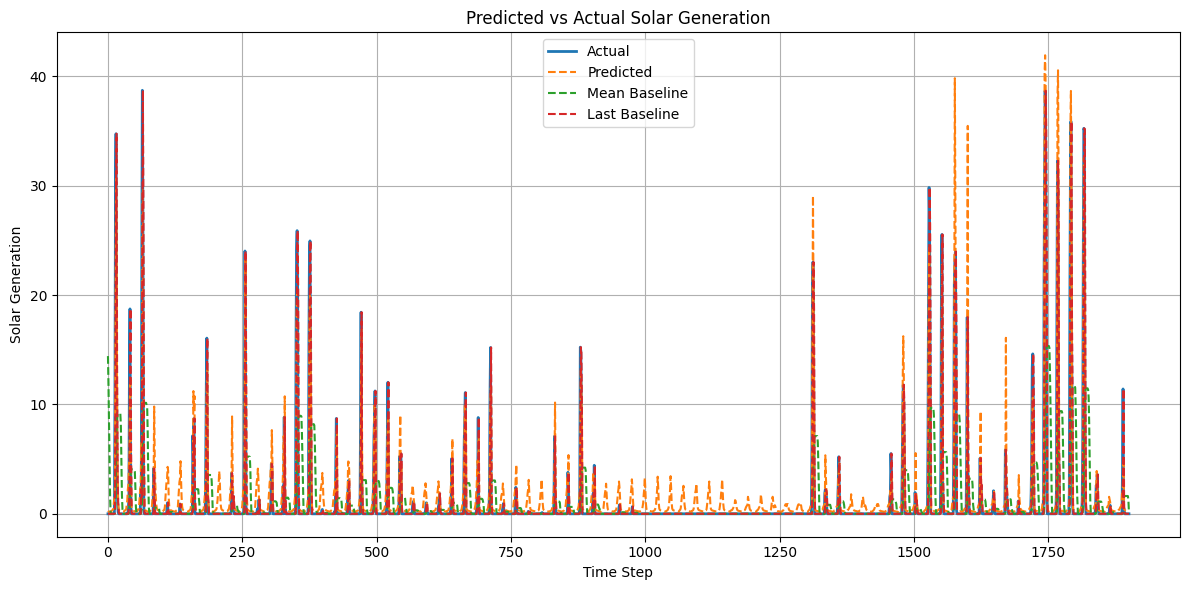

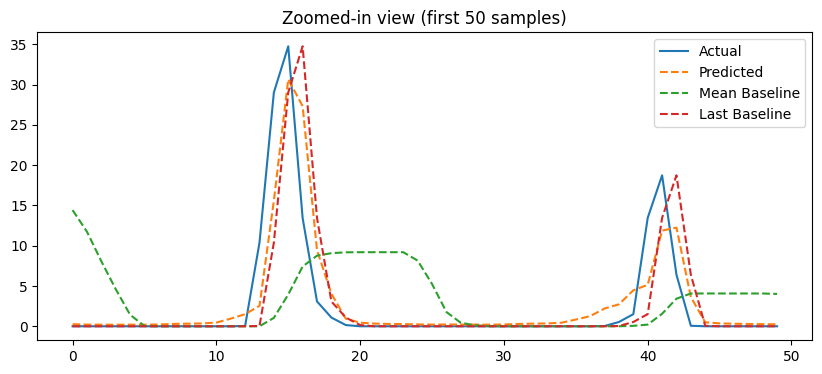

In [ ]:
evaluate_model(solar_model, solar_scaler_eval, solar_test_loader, "Solar")

In [ ]:
torch.save(solar_model, 'rye_transformer_solar_model.pth')

# Wind Forecasting

In [ ]:
# Loading forecasting data- solar, wind and load consumption data
wind_prod_data = df[['wind_production']]
# Creating the scalers
wind_scaler = MinMaxScaler()
wind_scaler_eval = MinMaxScaler()
wind_scaler_eval.fit(np.array(df['wind_production']).reshape(-1, 1))

# Create individual data loaders
wind_train_loader, wind_test_loader, wind_scaler = create_dataset(data=wind_prod_data, scaler=wind_scaler, input_length=10)

In [ ]:
# Model Hyperparameters
INPUT_DIM = 1
MODEL_DIM = 64
OUTPUT_DIM = 1
HEADS = 4
LAYERS = 2
DROPOUT = 0.1
WINDOW_SIZE = 10

In [ ]:
# Creating Wind Model
wind_model = TimeSeriesTransformer(INPUT_DIM, OUTPUT_DIM, MODEL_DIM, HEADS, LAYERS, DROPOUT, WINDOW_SIZE)
wind_criterion = nn.MSELoss()
wind_optim = optim.Adam(wind_model.parameters(), lr=1e-3)

# Train Wind Forecasting Model
NUM_EPOCHS = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
wind_model.to(device)
wind_model.train()
for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for batch_X, batch_y in wind_train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        wind_optim.zero_grad()
        output = wind_model(batch_X)
        loss = wind_criterion(output, batch_y)
        loss.backward()
        wind_optim.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(wind_train_loader):.4f}")

Epoch 1, Loss: 0.0516
Epoch 2, Loss: 0.0033
Epoch 3, Loss: 0.0017
Epoch 4, Loss: 0.0012
Epoch 5, Loss: 0.0010
Epoch 6, Loss: 0.0009
Epoch 7, Loss: 0.0009
Epoch 8, Loss: 0.0010
Epoch 9, Loss: 0.0009
Epoch 10, Loss: 0.0008
Epoch 11, Loss: 0.0008
Epoch 12, Loss: 0.0008
Epoch 13, Loss: 0.0008
Epoch 14, Loss: 0.0008
Epoch 15, Loss: 0.0008
Epoch 16, Loss: 0.0008
Epoch 17, Loss: 0.0008
Epoch 18, Loss: 0.0009
Epoch 19, Loss: 0.0008
Epoch 20, Loss: 0.0008
Epoch 21, Loss: 0.0008
Epoch 22, Loss: 0.0008
Epoch 23, Loss: 0.0008
Epoch 24, Loss: 0.0008
Epoch 25, Loss: 0.0008
Epoch 26, Loss: 0.0008
Epoch 27, Loss: 0.0008
Epoch 28, Loss: 0.0008
Epoch 29, Loss: 0.0008
Epoch 30, Loss: 0.0009
Epoch 31, Loss: 0.0008
Epoch 32, Loss: 0.0008
Epoch 33, Loss: 0.0008
Epoch 34, Loss: 0.0008
Epoch 35, Loss: 0.0008
Epoch 36, Loss: 0.0008
Epoch 37, Loss: 0.0008
Epoch 38, Loss: 0.0008
Epoch 39, Loss: 0.0008
Epoch 40, Loss: 0.0007
Epoch 41, Loss: 0.0008
Epoch 42, Loss: 0.0008
Epoch 43, Loss: 0.0007
Epoch 44, Loss: 0.00

Test MSE: 477.1630
Last Value (Baseline) MSE: 654.5278


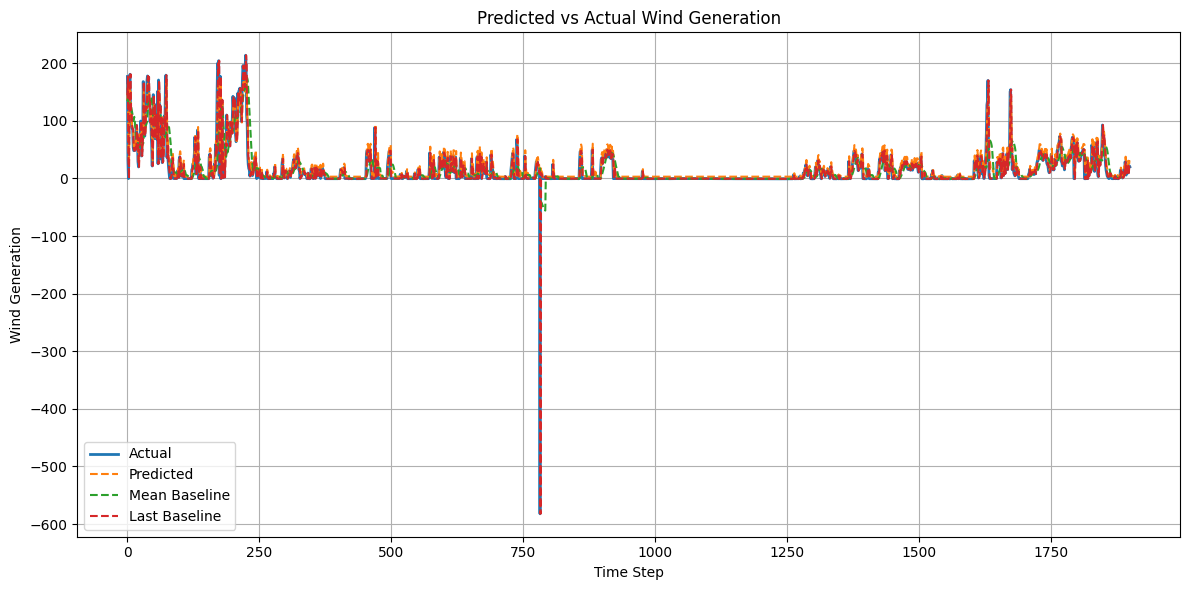

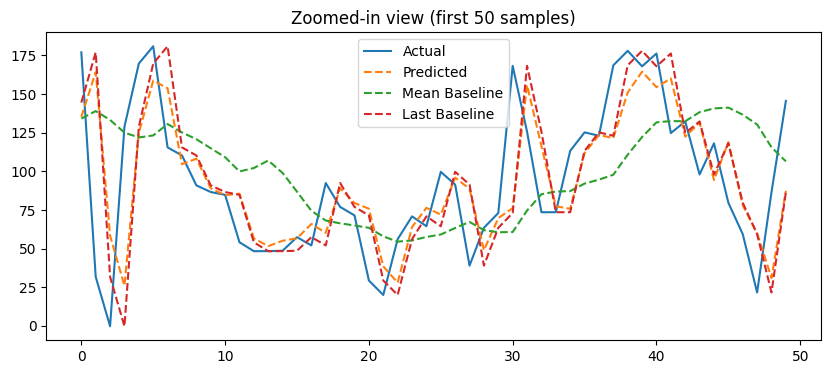

In [ ]:
evaluate_model(wind_model, wind_scaler_eval, wind_test_loader, "Wind")

In [ ]:
torch.save(wind_model, 'rye_transformer_wind_model.pth')

# Load Forecasting

In [50]:
# Loading forecasting data- solar, wind and load consumption data
load_data = df[['consumption', 'hour', 'month', 'dow']]
# Creating the scalers
load_scaler = MinMaxScaler()
load_scaler_eval = MinMaxScaler()
load_scaler_eval.fit(np.array(df['consumption']).reshape(-1, 1))

# Create individual data loaders
load_train_loader, load_test_loader, load_scaler = create_dataset(data=load_data, scaler=load_scaler, input_length=24)

In [54]:
# Model Hyperparameters
INPUT_DIM = 4
MODEL_DIM = 64
OUTPUT_DIM = 1
HEADS = 4
LAYERS = 2
DROPOUT = 0.1
WINDOW_SIZE = 24

In [55]:
# Creating Load Model
load_model = TimeSeriesTransformer(INPUT_DIM, OUTPUT_DIM, MODEL_DIM, HEADS, LAYERS, DROPOUT, WINDOW_SIZE)
load_criterion = nn.MSELoss()
load_optim = optim.Adam(load_model.parameters(), lr=1e-3)

# Train Load Forecasting Model
NUM_EPOCHS = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
load_model.to(device)
load_model.train()
for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for batch_X, batch_y in load_train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        load_optim.zero_grad()
        output = load_model(batch_X)
        loss = load_criterion(output, batch_y)
        loss.backward()
        load_optim.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(load_train_loader):.4f}")

Epoch 1, Loss: 0.0438
Epoch 2, Loss: 0.0078
Epoch 3, Loss: 0.0070
Epoch 4, Loss: 0.0067
Epoch 5, Loss: 0.0065
Epoch 6, Loss: 0.0059
Epoch 7, Loss: 0.0056
Epoch 8, Loss: 0.0054
Epoch 9, Loss: 0.0052
Epoch 10, Loss: 0.0052
Epoch 11, Loss: 0.0049
Epoch 12, Loss: 0.0048
Epoch 13, Loss: 0.0047
Epoch 14, Loss: 0.0047
Epoch 15, Loss: 0.0045
Epoch 16, Loss: 0.0045
Epoch 17, Loss: 0.0045
Epoch 18, Loss: 0.0044
Epoch 19, Loss: 0.0043
Epoch 20, Loss: 0.0047
Epoch 21, Loss: 0.0043
Epoch 22, Loss: 0.0044
Epoch 23, Loss: 0.0042
Epoch 24, Loss: 0.0043
Epoch 25, Loss: 0.0044
Epoch 26, Loss: 0.0042
Epoch 27, Loss: 0.0042
Epoch 28, Loss: 0.0041
Epoch 29, Loss: 0.0043
Epoch 30, Loss: 0.0041
Epoch 31, Loss: 0.0042
Epoch 32, Loss: 0.0044
Epoch 33, Loss: 0.0043
Epoch 34, Loss: 0.0042
Epoch 35, Loss: 0.0042
Epoch 36, Loss: 0.0041
Epoch 37, Loss: 0.0045
Epoch 38, Loss: 0.0043
Epoch 39, Loss: 0.0040
Epoch 40, Loss: 0.0044
Epoch 41, Loss: 0.0040
Epoch 42, Loss: 0.0040
Epoch 43, Loss: 0.0039
Epoch 44, Loss: 0.00

Test MSE: 29.6851
Last Value (Baseline) MSE: 45.4095


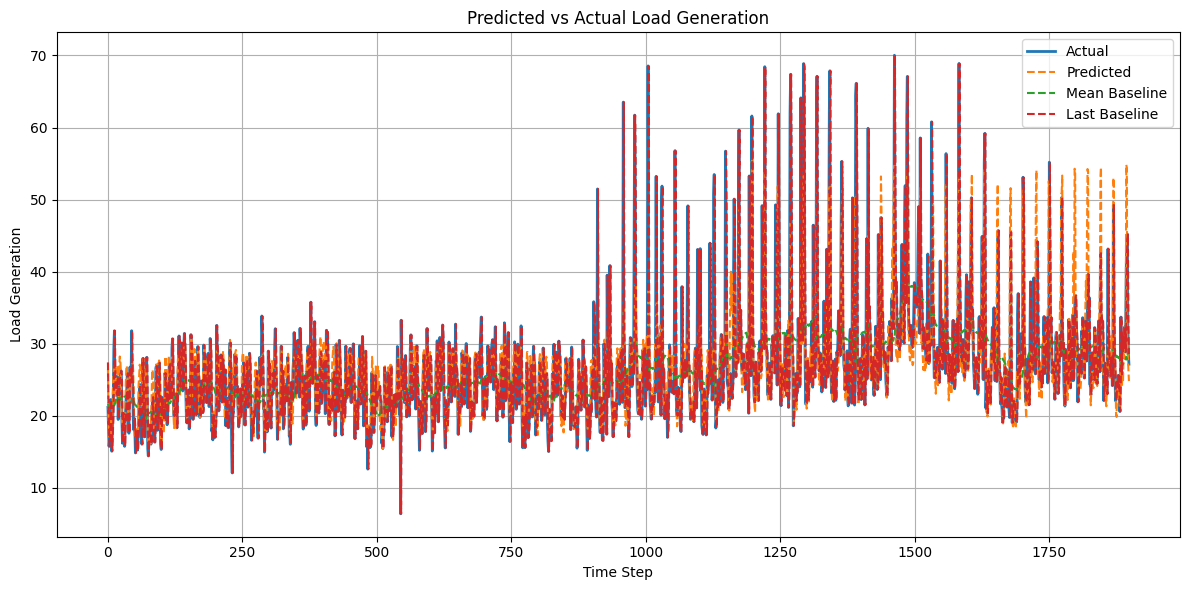

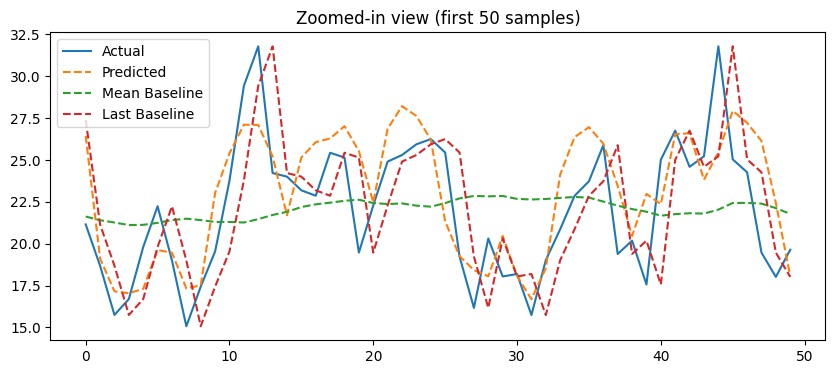

In [56]:
evaluate_model(load_model, load_scaler_eval, load_test_loader, "Load")

In [57]:
torch.save(load_model, "rye_transformer_load_model.pth")